Matriks jarak terpendek antar kota:
[[ 0. 14.  5. 16.  9.  9.  8. 10.  3.]
 [14.  0.  9.  8. 15. 13. 16. 16. 11.]
 [ 5.  9.  0. 13.  6.  4.  7.  7.  2.]
 [16.  8. 13.  0.  7.  9.  8.  8. 13.]
 [ 9. 15.  6.  7.  0.  2.  1.  1.  6.]
 [ 9. 13.  4.  9.  2.  0.  3.  3.  6.]
 [ 8. 16.  7.  8.  1.  3.  0.  2.  5.]
 [10. 16.  7.  8.  1.  3.  2.  0.  7.]
 [ 3. 11.  2. 13.  6.  6.  5.  7.  0.]]

Daftar kota: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', '#']
Masukkan kota awal: H
Masukkan kota akhir: D
Masukkan kota wajib (pisahkan koma, kosongkan jika tidak ada): #

Mencari rute terpendek dari H ke D wajib melewati ['#']...
Iterasi  20 | Jarak terbaik = 22.00
Iterasi  40 | Jarak terbaik = 22.00
Iterasi  60 | Jarak terbaik = 22.00
Iterasi  80 | Jarak terbaik = 22.00
Iterasi 100 | Jarak terbaik = 22.00

=== RUTE TERPENDEK ===
H -> E -> G -> # -> C -> F -> D
Total jarak = 22.00



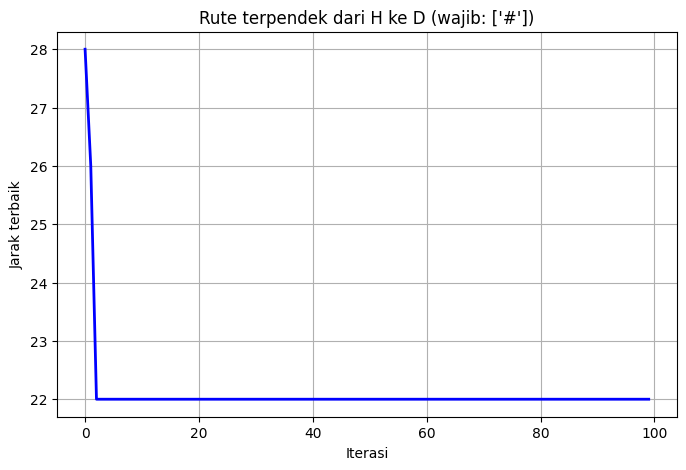

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# =============================================================================
# 1. MEMBANGUN MATRIKS JARAK
# =============================================================================
# Daftar semua kota (termasuk '#' sebagai node khusus)
kota = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', '#']
n = len(kota)                         # jumlah kota
idx = {kota[i]: i for i in range(n)}  # mapping nama -> indeks

INF = 1e9
dist = np.full((n, n), INF)         # matriks jarak langsung (awal tak terhingga)
np.fill_diagonal(dist, 0)           # jarak ke diri sendiri = 0

# Data koneksi antar kota (graf tidak berarah)
koneksi = [
    ('A', 'C', 6), ('A', '#', 3), # yang menghubungkan titik A
    ('B', 'C', 9), ('B', 'D', 8), # yang menghubungkan titik B
    ('C', 'A', 6), ('C', 'B', 9), ('C', '#', 2), ('C', 'F', 4), # yang menghubungkan titik C
    ('D', 'B', 8), ('D', 'E', 7), ('D', 'H', 9), # yang menghubungkan titik D
    ('E', 'D', 7), ('E', 'F', 2), ('E', 'G', 1), ('E', 'H', 1), # yang menghubungkan titik E
    ('F', 'C', 4), ('F', 'E', 2), # yang menghubungkan titik F
    ('G', 'E', 1), ('G', 'H', 3), ('G', '#', 5), # yang menghubungkan titik G
    ('H', 'D', 9), ('H', 'E', 1), ('H', 'G', 3), # yang menghubungkan titik H
    ('#', 'A', 3), ('#', 'C', 2), ('#', 'G', 5) # yang menghunungkan titik "#
    "
]

# Isi matriks jarak langsung (simetris)
for (dari, ke, jarak) in koneksi:
    i, j = idx[dari], idx[ke]
    dist[i, j] = jarak
    dist[j, i] = jarak

# -------------------------------------------------------------------------
# Floyd-Warshall: mencari jarak terpendek antara SEMUA pasangan kota
# -------------------------------------------------------------------------
shortest = dist.copy()
for k in range(n):
    for i in range(n):
        if shortest[i, k] == INF:
            continue
        for j in range(n):
            if shortest[k, j] == INF:
                continue
            if shortest[i, k] + shortest[k, j] < shortest[i, j]:
                shortest[i, j] = shortest[i, k] + shortest[k, j]

# Pastikan graf terhubung (tidak ada INF yang tersisa)
if np.any(shortest == INF):
    print("Graf tidak terhubung! Tidak dapat mencari rute.")
    exit()

print("Matriks jarak terpendek antar kota:")
print(shortest)

# =============================================================================
# 2. INPUT DARI USER
# =============================================================================
print("\nDaftar kota:", kota)
start_nama = input("Masukkan kota awal: ").strip()
end_nama   = input("Masukkan kota akhir: ").strip()
wajib_input = input("Masukkan kota wajib (pisahkan koma, kosongkan jika tidak ada): ").strip()
wajib_list = [x.strip() for x in wajib_input.split(',')] if wajib_input else []

# Validasi input
if start_nama not in kota or end_nama not in kota:
    print("Kota awal/akhir tidak valid!")
    exit()
for w in wajib_list:
    if w not in kota:
        print(f"Kota wajib {w} tidak valid!")
        exit()

start = idx[start_nama]
end   = idx[end_nama]
wajib_indices = [idx[w] for w in wajib_list]

# =============================================================================
# 3. ALGORITMA ANT COLONY OPTIMIZATION (ACO)
# =============================================================================

n_ants = 10  # jumlah semut dalam satu iterasi
n_iter = 100 # jumlah iterasi maksimum
alpha = 1.0  # pengaruh feromon (semakin besar, semakin mengikuti jejak semut lain)
beta  = 2.0  # pengaruh jarak (semakin besar, semakin memilih kota terdekat)
rho   = 0.5  # laju penguapan feromon (0 - 1)
Q     = 1.0  # konstanta untuk deposit feromon

# Matriks feromon berukuran n x n (nilai awal kecil)
pheromone = np.full((n, n), 0.1)
np.fill_diagonal(pheromone, 0.0)   # feromon dari kota ke diri sendiri diabaikan

def hitung_jarak_tur(tur):
    """
    Menghitung total jarak suatu tur (rute) menggunakan matriks jarak terpendek.
    tur: list of indeks kota (berurutan)
    """
    return sum(shortest[tur[i], tur[i+1]] for i in range(len(tur)-1))

def semua_wajib_dikunjungi(dikunjungi):
    """dikunjungi: list boolean panjang n, True jika kota sudah dikunjungi."""
    return all(dikunjungi[w] for w in wajib_indices)

def pilih_kota_berikutnya(sekarang, dikunjungi):
    """
    Memilih kota berikutnya berdasarkan probabilitas:
    - feromon (tau) dan kebalikan jarak (eta)
    - Kota yang sudah dikunjungi tidak dipertimbangkan.
    """
    prob = []
    for calon in range(n):
        if not dikunjungi[calon]:
            tau = pheromone[sekarang, calon] ** alpha
            eta = (1.0 / shortest[sekarang, calon]) ** beta
            prob.append(tau * eta)
        else:
            prob.append(0.0)
    prob = np.array(prob)
    if prob.sum() == 0:
        # Jika tidak ada probabilitas >0, pilih sembarang kota yang belum dikunjungi
        belum = [k for k in range(n) if not dikunjungi[k]]
        return random.choice(belum) if belum else None
    prob = prob / prob.sum()
    return np.random.choice(range(n), p=prob)

def bangun_tur():
    """
    Membangun satu rute lengkap oleh seekor semut.
    Mulai dari `start`, berhenti ketika sudah mencapai `end` DAN semua kota wajib sudah dikunjungi.
    Menggunakan aturan pemilihan kota secara probabilistik.
    """
    tur = [start]
    dikunjungi = [False] * n
    dikunjungi[start] = True

    while True:
        sekarang = tur[-1]
        # Kondisi berhenti: sudah di kota tujuan dan semua wajib sudah dilewati
        if sekarang == end and semua_wajib_dikunjungi(dikunjungi):
            break
        berikutnya = pilih_kota_berikutnya(sekarang, dikunjungi)
        if berikutnya is None:   # tidak ada kota yang bisa dipilih (seharusnya tidak terjadi)
            break
        tur.append(berikutnya)
        dikunjungi[berikutnya] = True

    return tur

# Variabel untuk menyimpan rute terbaik global
best_tur = None
best_jarak = float('inf')
history = []   # menyimpan jarak terbaik setiap iterasi (untuk plot konvergensi)

print(f"\nMencari rute terpendek dari {start_nama} ke {end_nama} "
      f"wajib melewati {wajib_list if wajib_list else 'tidak ada'}...")

# -------------------------------------------------------------------------
# Loop utama ACO atau iteration
# -------------------------------------------------------------------------
for it in range(n_iter):
    semua_tur = []
    semua_jarak = []

    # 1. Bangun rute untuk setiap semut
    for _ in range(n_ants):
        tur = bangun_tur()
        jarak = hitung_jarak_tur(tur)
        semua_tur.append(tur)
        semua_jarak.append(jarak)

        # Perbarui rute terbaik jika rute ini valid (mencapai end & semua wajib)
        if tur[-1] == end and all(k in tur for k in wajib_indices):
            if jarak < best_jarak:
                best_jarak = jarak
                best_tur = tur.copy()

    # 2. Update feromon (penguapan + deposit)
    pheromone *= (1 - rho)                # penguapan
    for tur, jarak in zip(semua_tur, semua_jarak):
        deposit = Q / jarak
        for i in range(len(tur)-1):
            a, b = tur[i], tur[i+1]
            pheromone[a, b] += deposit
            pheromone[b, a] += deposit    # feromon simetris

    # Simpan jarak terbaik untuk plot
    history.append(best_jarak)

    # Cetak progres setiap 20 iterasi
    if (it+1) % 20 == 0:
        print(f"Iterasi {it+1:3d} | Jarak terbaik = {best_jarak:.2f}")

# =============================================================================
# 4. MENAMPILKAN HASIL AKHIR
# =============================================================================
print("\n=== RUTE TERPENDEK ===")
if best_tur is None:
    print("Tidak ditemukan rute yang memenuhi semua kota wajib dan berakhir di kota tujuan.")
else:
    rute_nama = [kota[i] for i in best_tur]
    print(" -> ".join(rute_nama))
    print(f"Total jarak = {best_jarak:.2f}")
    print("")

    # Plot grafik konvergensi
    plt.figure(figsize=(8,5))
    plt.plot(history, 'b-', linewidth=2)
    plt.title(f'Rute terpendek dari {start_nama} ke {end_nama} (wajib: {wajib_list})')
    plt.xlabel('Iterasi')
    plt.ylabel('Jarak terbaik')
    plt.grid(True)
    plt.show()